[Last week](https://buttondown.com/jaffray/archive/simulating-queueing/) we simulated a queueing algorithm. Behind the scenes, I did this by writing a Go program and placing sleeps to simulate processing. This meant that running a simulation took a while. I ran each one for about a minute, and adding more simulations where I varied parameters took longer and longer. How might we run simulations that don't use the real computer clock?

One way to model such a thing is as a stream of *events*, which is a stream of tuples of `(time passed before something happened, what happened)`. If we have several of such streams, we can merge them with a k-way merge to turn them into a single stream. And this way certainly works!

But! As we know from [Adventures in Probability](https://buttondown.com/jaffray/archive/adventures-in-probability/) there are simpler ways if we are willing to restrict ourselves to the exponential distribution and exploit its properties. So let's do that. I'm going to write this entire post from within a Jupyter notebook because I realized I probably could, and that seemed fun.

We'll start by creating the notion of a "process," which is simply a thing that tells us "after you waited this amount of time, this thing happened." All of our processes are exponentially distributed. Or, they follow a Poisson process.

Let's begin with some imports.

In [ ]:
import random
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import xxhash

A `SingleProcess` is constructed by a rate ("how many times per second") and a description of what happened.

In [771]:
class SingleProcess:
    def __init__(self, value, rate):
        self.rate = rate
        self.value = value

    def next(self):
        return (random.expovariate(self.rate), self.value)

Imagine we're sitting on our porch, watching cars go by. One car comes by about once every ten seconds. We can simulate this like so:

In [772]:
cars = SingleProcess('car', 0.1)

We can add a helper to plot a sequence of events:

In [773]:
COLOR_MAP = {'red': 'red', 'blue': 'blue'}

def plot_cars(events):
    buckets = {}
    for t, val in events:
        buckets.setdefault(val, []).append(t)

    colors = [COLOR_MAP.get(v, 'black') for v in buckets]
    plt.subplots(figsize=(10, 1.5))
    plt.eventplot(list(buckets.values()), colors=colors, lineoffsets=[0] * len(buckets))
    plt.xlabel("time (seconds)")
    plt.yticks([])
    plt.show()

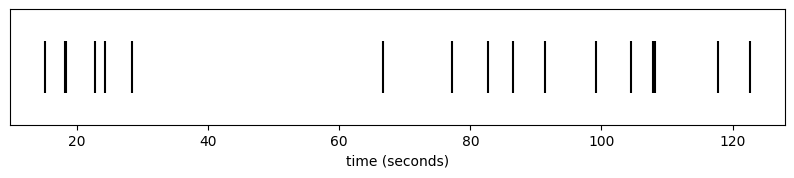

In [774]:
t = 0
arrivals = []
while t < 120:
    dt, val = cars.next()
    t += dt
    arrivals.append((t, val))

plot_cars(arrivals)

In [775]:
def plot_completed(completed, **kwargs):
    plt.bar(range(len(completed)), completed, **kwargs)
    plt.xlabel("client")
    plt.ylabel("completed jobs")
    plt.show()

Perhaps rather than just tracking *whether* we saw a car, our road is populated by blue cars and red cars. There are twice as many blue cars as red cars. We could simulate this process by, every time we see a car, we decide if it's red or if it's blue. We can introduce a `Map` higher order distribution that transforms an input distribution in some way to accomplish this.

In [776]:
class Map:
    def __init__(self, dist, f):
        self.dist = dist
        self.f = f
    
    def next(self):
        dt, v = self.dist.next()
        return (dt, self.f(v))

In [777]:

coloured_cars = Map(cars, lambda _: 'red' if random.random() < 1.0/3 else 'blue')
(dt, col) = coloured_cars.next()
print(f"after {dt} seconds, we saw a {col} car")

after 7.465154350534022 seconds, we saw a blue car


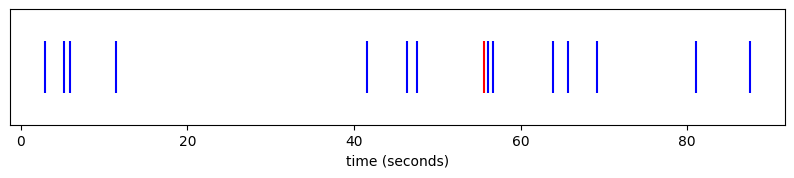

In [778]:
t = 0
arrivals = []
while True:
    dt, color = coloured_cars.next()
    t += dt
    if t > 120:
        break
    arrivals.append((t, color))

plot_cars(arrivals)

The power of the exponential distribution is that doing it this way is equivalent to taking a distribution of blue cars and a distribution of red cars and "racing" them. We *could* do this via a k-way merge of the streams, but we can also just construct a new distribution whose rate is the sum of their rates, and who picks an outcome proportional to its rate:

In [779]:
class Merge:
    def __init__(self, *dists):
        flat = []
        for d in dists:
            if isinstance(d, Merge):
                flat.extend(d.dists)
            else:
                flat.append(d)
        self.rate = sum(d.rate for d in flat)
        self.dists = flat
        self.weights = [d.rate for d in flat]
    
    def next(self):
        dt = random.expovariate(self.rate)
        (_, v) = random.choices(self.dists, self.weights)[0].next()
        return (dt, v)

As an aside, this would also be a good place to use something like a [Huffman sampler](https://buttondown.com/jaffray/archive/discrete-distributions/).

In [780]:
red_cars = SingleProcess('red', 0.1 * 1/3) # one every thirty seconds
blue_cars = SingleProcess('blue', 0.1 * 2/3) # one every fifteen seconds

coloured_cars = Merge(red_cars, blue_cars)

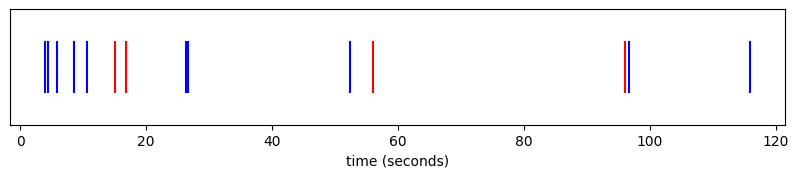

In [781]:
t = 0
arrivals = []
while True:
    dt, color = coloured_cars.next()
    t += dt
    if t > 120:
        break
    arrivals.append((t, color))

plot_cars(arrivals)

This is all the power we need to be able to simulate many queueing problems.

Recall our problem from last week where we had a handful of normal, well behaved clients each submitting some number of requests per second:

In [782]:
MESSAGE_RATE = 10

clients = Merge(*[SingleProcess({"type": "client_message", "id": i}, MESSAGE_RATE) for i in range(0, 10)])


This gives us an ordered stream of events denoting which of the clients was the next to send a message:

In [783]:
for i in range(5):
    (dt, v) = clients.next()
    id = v["id"]
    print(f"after {dt} seconds, client {id} sent a message")

after 0.004386791041885512 seconds, client 5 sent a message
after 0.02876165070273449 seconds, client 6 sent a message
after 0.003424278034820556 seconds, client 2 sent a message
after 0.0054703066993901876 seconds, client 6 sent a message
after 0.001414782627861562 seconds, client 7 sent a message


On top of this, we can model "completing" a job the same way, as a Poisson process separated by some exponentially distributed times:

In [784]:
processor = SingleProcess({"type": "job_complete"}, 30)

(dt, _) = processor.next()
print(f"finished a job after {dt}s")

finished a job after 0.05048711928106848s


By racing these, we can interleave job completions and insertions.

In [785]:
events = Merge(
    clients,
    processor,
)

for i in range(10):
    dt, v = events.next()
    match v["type"]:
        case "client_message":
            id = v["id"]
            print(f"after {dt} seconds, client {id} sent a message")
        case "job_complete":
            print(f"after {dt} seconds, we finished a job")

after 0.005764186526403466 seconds, client 7 sent a message
after 0.00465533062482504 seconds, client 5 sent a message
after 0.0015676852871998766 seconds, client 4 sent a message
after 0.010365648595726555 seconds, client 2 sent a message
after 0.0009288567365624816 seconds, client 6 sent a message
after 0.0015787495788004407 seconds, client 9 sent a message
after 0.026969823053653762 seconds, client 8 sent a message
after 0.01863429075742134 seconds, we finished a job
after 0.011290741251733594 seconds, we finished a job
after 0.010079513428735651 seconds, client 6 sent a message


We can simulate a queueing system really easily now, by keeping a state machine that's driven by the events of the events of our system.

Here is a system that uses a single queue:

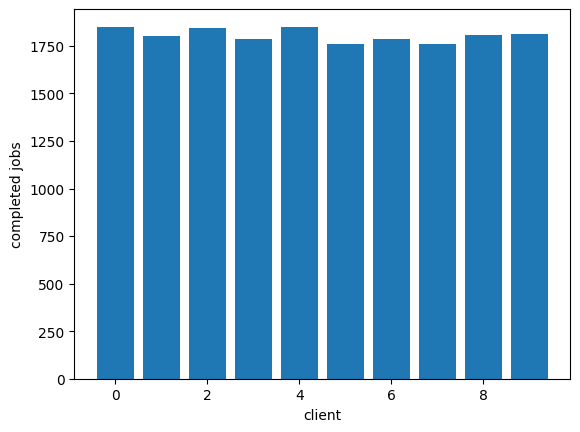

In [786]:
CLIENT_COUNT = 10

events = Merge(
    *[SingleProcess({"type": "client_message", "id": i}, 5) for i in range(0, CLIENT_COUNT)],
    SingleProcess({"type": "job_complete"}, 30)
)

RUN_SECONDS = 600
MAX_QUEUE_LEN = 10

t = 0
queue = deque()
completed = [0] * CLIENT_COUNT

while t < RUN_SECONDS:
    dt, ev = events.next()
    t += dt
    match ev["type"]:
        case "client_message":
            if len(queue) < MAX_QUEUE_LEN:
                queue.append(ev["id"])
        case "job_complete":
            if len(queue) > 0:
                completed[queue[0]] += 1
                queue.popleft()

plot_completed(completed)

Now we can easily see that adding a noisy client, that noisy client can easily dominate and make it so the other clients can't get much work done:

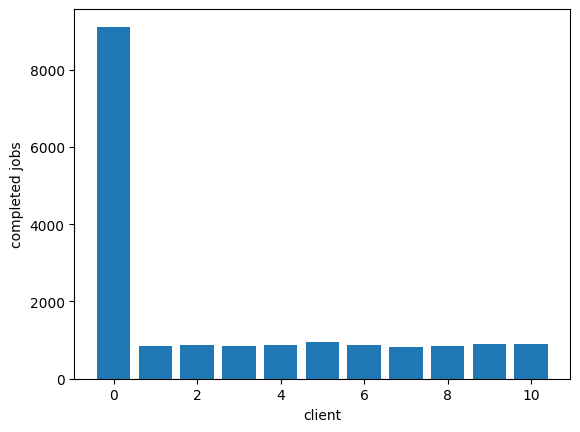

In [787]:
CLIENT_COUNT = 10

events = Merge(
    SingleProcess({"type": "client_message", "id": 0}, 50),
    *[SingleProcess({"type": "client_message", "id": i+1}, 5) for i in range(0, CLIENT_COUNT)],
    SingleProcess({"type": "job_complete"}, 30)
)

RUN_SECONDS = 600
MAX_QUEUE_LEN = 10

t = 0
queue = deque()
completed = [0] * (CLIENT_COUNT+1)

while t < RUN_SECONDS:
    dt, ev = events.next()
    t += dt
    match ev["type"]:
        case "client_message":
            if len(queue) < MAX_QUEUE_LEN:
                queue.append(ev["id"])
        case "job_complete":
            if len(queue) > 0:
                completed[queue[0]] += 1
                queue.popleft()

plot_completed(completed)

We can get fair servicing of these clients by giving them each their own queue and having the processor round-robin its work to fill them in. This is "fair queuing:"

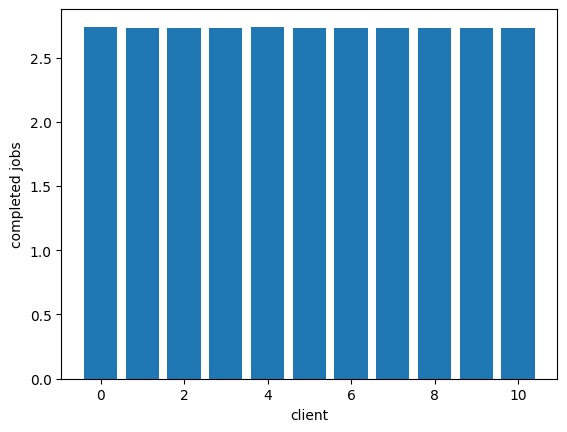

In [788]:
CLIENT_COUNT = 10

events = Merge(
    SingleProcess({"type": "client_message", "id": 0}, 50),
    *[SingleProcess({"type": "client_message", "id": i+1}, 5) for i in range(0, CLIENT_COUNT)],
    SingleProcess({"type": "job_complete"}, 30)
)

RUN_SECONDS = 600
MAX_QUEUE_LEN = 10

t = 0
queues = [deque() for _ in range(CLIENT_COUNT + 1)]
completed = [0] * (CLIENT_COUNT + 1)
processor_idx = 0

while t < RUN_SECONDS:
    dt, ev = events.next()
    t += dt
    match ev["type"]:
        case "client_message":
            q = queues[ev["id"]]
            if len(q) < MAX_QUEUE_LEN:
                q.append(ev["id"])
        case "job_complete":
            start_idx = processor_idx
            while True:
                q = queues[processor_idx]
                processor_idx = (processor_idx + 1) % len(queues)
                if len(q) > 0:
                    completed[q[0]] += 1
                    q.popleft()
                    break
                if processor_idx == start_idx:
                    break

plot_completed([c/RUN_SECONDS for c in completed])

As Marc says, this comes with problems, though. We have O(n) queues, which we might rather avoid. This is where we can introduce SFQ as described by Marc to improve things:

In [ ]:
CLIENT_COUNT = 10
NUM_QUEUES = 4
PERTURBATION_INTERVAL = 30

events = Merge(
    SingleProcess({"type": "client_message", "id": 0}, 50),
    *[SingleProcess({"type": "client_message", "id": i+1}, 5) for i in range(0, CLIENT_COUNT)],
    SingleProcess({"type": "job_complete"}, 30)
)

RUN_SECONDS = 600
MAX_QUEUE_LEN = 10

def sfq_hash(client_id, seed):
    return xxhash.xxh3_64_intdigest(f"{seed}:{client_id}".encode()) % NUM_QUEUES

t = 0
queues = [deque() for _ in range(NUM_QUEUES)]
completed = [0] * (CLIENT_COUNT + 1)
processor_idx = 0

while t < RUN_SECONDS:
    dt, ev = events.next()
    t += dt
    seed = int(t) // PERTURBATION_INTERVAL
    match ev["type"]:
        case "client_message":
            idx = sfq_hash(ev["id"], seed)
            if len(queues[idx]) < MAX_QUEUE_LEN:
                queues[idx].append(ev["id"])
        case "job_complete":
            start_idx = processor_idx
            while True:
                q = queues[processor_idx]
                processor_idx = (processor_idx + 1) % NUM_QUEUES
                if len(q) > 0:
                    completed[q[0]] += 1
                    q.popleft()
                    break
                if processor_idx == start_idx:
                    break

plot_completed(completed)